---
title: |
  Tokens and Embeddings
subtitle: |
  Building blocks for processing sequence data.
jupyter: python3
---

{{< include ../assets/includes/_colab-link.qmd >}}

::: {.content-hidden}

## Boilerplate preamble for LaTeX macros and Python viz style
$$
{{< include ../assets/includes/_macros.tex >}}
$$

In [ ]:
import style

:::

In this set of notes, we begin our study of language models with two key concepts: **tokens**, the building blocks of sequence data, and **embeddings**, the vector representations of those tokens that allow us to apply machine learning techniques to them. By the end of these notes, we'll have implemented and trained one standard embedding model using a small text data set. 

In [ ]:
#| code-fold: true
import torch 
import torch
from torchinfo import summary
from torch import nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import urllib
import pandas as pd
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt

# for appearance
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"
pio.renderers.default = "notebook_connected"

Our example for this lecture will be a combined corpus of the complete text of several books by Dr. Seuss, including *Green Eggs and Ham*, *The Cat in the Hat*,  *Fox in Socks*, and *How The Grinch Stole Christmas*. The text is available online, and we can load it directly into Python using `urllib`.

In [ ]:
url = "https://raw.githubusercontent.com/PhilChodrow/ml-notes-update/refs/heads/main/data/seuss.txt"
text = "\n".join([line.decode('utf-8').strip() for line in urllib.request.urlopen(url)])

Here is an excerpt from the text: 

In [ ]:
print(text[0:132])

The Cat in the Hat

By Dr. Seuss

The sun did not shine.
It was too wet to play.
So we sat in the house
All that cold, cold, wet day


## Tokenization

Our first order of business is to represent the text in standardized form which we can eventually feed into models. The most common approach in modern language modeling is *tokenization*. 

::: {#def-tokenization}

## Tokenizer, Tokens, Vocabulary

A *tokenizer* is a map between (typically short) sequences of raw text and integer labels called *tokens*. The set of all tokens is called the *vocabulary* of the tokenizer.

:::

It's possible to implement and train many modern tokenizers from scratch, but for our purposes here we'll use a pre-trained tokenizer. This particular tokenizer is the one used by the GPT-2 language model, and it is available through the `transformers` library. [GPT-2 preceded GPT-3, the version of GPT that became popular through ChatGPT.]{.aside}

In [ ]:
from tokenizers import Tokenizer
from transformers import AutoTokenizer, AutoModelForCausalLM

# GPT2 tokenizer and model
checkpoint = "openai-community/gpt2"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

Here are a few tokens from the vocabulary, along with their corresponding integer labels:

::: {#fig-vocab }

In [ ]:
vocab_df = pd.DataFrame(list(tokenizer.vocab.items()), columns=["Token", "ID"])
vocab_df.head(10)

,Token,ID
0,conference,41124
1,ĠQuin,29338
2,ĠBC,11843
3,Ġrigging,48784
4,Ġeroded,44699
5,hett,17442
6,ĠCanyon,22099
7,Ġherself,5223
8,ĠHol,6479
9,Arizona,40732


Excerpt from the vocabulary of the GPT-2 tokenizer. 

:::

[You'll notice the presence of the special character `Ġ` in some of the tokens. This character is used by the GPT-2 tokenizer to indicate that the token is preceded by a space in the original text. For example, the token `Ġthe` corresponds to the word "the" when it appears after a space, while the token `the` corresponds to "the" when it appears at the beginning of a string or after certain punctuation. This point is just one of many subtleties in play when creating a tokenizer that captures English text relatively faithfully.]{.aside} 

Once we've created the tokenizer, we can use the `encode` method to convert any supplied text into a sequence of tokens.

In [ ]:
#---
sentence = "I do not like green eggs and ham."
tokens = tokenizer.encode(sentence)
#---

token_df = pd.DataFrame({"Token": tokens})
token_df["Text"] = token_df["Token"].apply(lambda x: tokenizer.decode(x))
token_df.head(10)

,Token,Text
0,40,I
1,466,do
2,407,not
3,588,like
4,4077,green
5,9653,eggs
6,290,and
7,8891,ham
8,13,.


We can then `decode` the tokens back into text:

In [ ]:
#---
decoded = tokenizer.decode(tokens)
print(decoded)
#---

I do not like green eggs and ham.


The complete GPT-2 tokenizer has a large vocabulary of tokens: 

In [ ]:
print("Vocabulary size:", tokenizer.vocab_size)

Vocabulary size: 50257


This is quite a bit more than the number of unique tokens which actually appear in our text data set.

In [ ]:
#---
tokens = tokenizer.encode(text)
unique_tokens = set(tokens)
#---
print("Total number of tokens in text:", len(tokens))
print("Number of unique tokens in text:", len(unique_tokens))

Token indices sequence length is longer than the specified maximum sequence length for this model (11051 > 1024). Running this sequence through the model will result in indexing errors


Total number of tokens in text: 11051
Number of unique tokens in text: 1589


Later in these notes, we'll find it useful to distinguish tokens which are actually present in our corpus from those which are not. 

## Token Embedding

Token ids themselves are not usually suitable inputs for machine learning models because they aren't semantically meaningful. The integer id is interpreted as an *index* rather than a *quantity* -- for example, the token with id 100 isn't necessarily more similar to the token with id 101 than it is to the token with id 500. To address this issue, we need to convert token ids into *feature vectors* that capture semantic information about the tokens. This process is called *embedding*.

::: {#def-embedding}

## Token Embedding

A *token embedding* is a function $f: \{1,2,\ldots,\text{vocab\_length}\} \to \R^d$ that maps each token id to a vector in $\R^d$. The integer $d$ is called the *embedding dimension*.

:::

### One-Hot Encoding

One way to convert token ids into feature vectors is to assign a unique vector to each token id via *one-hot encoding*. 

As our first attempt to convert token ids into feature vectors, we'll use *one-hot encoding*: we represent each token as a vector of zeros with a single one in the position corresponding to the token's id. 

::: {#def-one-hot}

## One-Hot Encoding

The *one-hot encoding* of a token id $i$ is the vector in $\R^d$ which has a one in the $i$-th position and zeros everywhere else. [Linear algebra fans in the room may also call this the $i$th *standard basis vector*.]{.aside}

:::

If we wanted to represent a sequence of tokens for input into a model, we could use one-hot encoding to convert each token into a vector, and then concatenate those vectors together. The result would be a feature vector of length $d \cdot n$ for a sequence of $n$ tokens, where $d$ is the size of the vocabulary.


::: {#fig-one-hot}

![](fig/one-hot.png)

Visual illustration of one-hot encoding: the second sequence in the data set has token ids `[1, 3, 4, 1]`. 

:::

### Limitations of One-Hot Encoding

There are two important limitations to one-hot encoding tokens as a method for feature engineering. 

#### Computational: Feature Vectors Too Large 

In the previous batch of models, we associated to each token a one-hot vector of length equal to the number of distinct tokens in the vocabulary. This meant that a given sequence of length $k$ was represented by a vector of length $k \cdot \text{vocab\_length}$; this can quickly become impractical if we wish for either a large vocabulary or a long context length. In the case of even our short Dr. Seuss text, there are over 1,500 unique tokens. A one-hot encoding of a single token therefore requires a feature vector of length 1,500, and a sequence of 10 tokens would require a feature vector of length 15,000. This is not only computationally expensive, but also likely to lead to overfitting. 

#### Semantic: Feature Vectors Not Meaningful 

Since machine learning models are constructed from linear algebraic operations, the *geometry* of the feature vectors is our primary tool for expressing *semantic* relationships between tokens. There are a few ways to express linear algebraic relationships between vectors. A very common approach in the context of token embeddings is to use the *inner product* between vectors as a measure of similarity: 

$$
\begin{aligned}
    \brackets{\vu, \vv} = \vu \cdot \vv = \sum_{i=1}^d u_i v_i\;.
\end{aligned}
$$

Since it's possible that $\vu$ and $\vv$ might have very different magnitudes, it's common to normalize the inner product by the magnitudes of the vectors, which gives us the *cosine similarity*:

::: {#def-cosine-similarity}

## Cosine Similarity

The *cosine similarity* between two vectors $\vu$ and $\vv$ is defined as
$$
\begin{aligned}
    \text{CS}(\vu, \vv) = \frac{\brackets{\vu, \vv}}{\norm{\vu} \norm{\vv}}\;.
\end{aligned}
$$ 

The cosine similarity is a number between -1 and 1, where 1 indicates $\vu$ and $\vv$ are parallel (i.e. $\vv = c \vu$ for some $c > 0$), -1 indicates $\vu$ and $\vv$ are anti-parallel (i.e. $\vv = c \vu$ for some $c < 0$), and 0 indicates $\vu$ and $\vv$ are orthogonal (i.e. $\brackets{\vu, \vv} = 0$).
:::

Here's a simple implementation: 

In [ ]:
#---
def cosine_similarity(u, v):
    return u@v / (torch.norm(u) * torch.norm(v))
#---

Cosine similarity highlights a major issue with one-hot encoding: all the feature vectors are orthogonal, which means that $\mathrm{CS}(\vv_i, \vv_j) = 0$ for any two distinct tokens $i$ and $j$. This is a missed opportunity: for example, we might expect that the tokens "cat" and "dog" are somewhat more similar to each other than either is to "chair," but this idea of similarity is not captured by one-hot encoding.

## Learned Embeddings

Of course, we *also* don't want to have to try to write down by hand what better feature vectors for our tokens would look like. So, in the usual spirit of machine learning, we can aim to learn meaningful representations of the tokens *from data*. There are many approaches to learning token embeddings, of which a few well-known examples are Word2Vec [@mikolov2013distributed], GloVe [@pennington2014glove], and Continuous Bag Of Words (CBOW). [These approaches are not all disjoint; for example, CBOW is one possible subroutine in the Word2Vec framework.]{.aside} In this set of notes, we'll implement and train a simple version of the CBOW model. 

### CBOW: Continuous Bag of Words

CBOW, like many other embedding models, learns token embeddings from a prediction task: we try to predict a target token $t_k$ from its surrounding tokens $t_{k-c}, \ldots, t_{k-1}, t_{k+1}, \ldots, t_{k+c}$, where $c$ is a hyperparameter called the *context length*. The model learns token embeddings by learning to solve this prediction task. We're going to consider a very simple version of the CBOW model in which we predict $t_k$ from a single context token at a time. This means we need a data set that looks like this: 

In [ ]:
example = "I do not like green eggs and ham."

#---
example_tokens = tokenizer.encode(example)

context_length = 2
data = []
for i in range(context_length, len(example_tokens)-context_length):
    for j in range(-context_length, context_length+1):
        if j != 0:
            data.append((example_tokens[i+j], example_tokens[i]))
#---

for context, target in data:
    print(f"{tokenizer.decode(context):<6} --> {tokenizer.decode(target)}")

I      -->  not
 do    -->  not
 like  -->  not
 green -->  not
 do    -->  like
 not   -->  like
 green -->  like
 eggs  -->  like
 not   -->  green
 like  -->  green
 eggs  -->  green
 and   -->  green
 like  -->  eggs
 green -->  eggs
 and   -->  eggs
 ham   -->  eggs
 green -->  and
 eggs  -->  and
 ham   -->  and
.      -->  and


A nice feature of this data set is that it contains many examples of the same target token appearing in different contexts, which allows the model to learn a more general embedding for that token. For example, the token "green" appears in the context of "like" and "eggs," which should help the model learn an embedding for "green" that captures its relationship to those other tokens. This also helps guard against overfitting -- the model can't just memorize the embedding for "green" based on a single context, since it appears in multiple contexts.

The following dataset class implements this data generation process for the entire example text of Dr. Seuss. [This data set also includes logic for converting the token indices from the GPT tokenizer to a contiguous integer representation which includes only indices for the tokens which are present in the data set. This allows our model later to learn embeddings for ~1,500 tokens, rather than the full vocabulary of ~50,000.]{.aside}

In [ ]:
from torch.utils.data import Dataset, DataLoader
class CBOWDataset(Dataset):
    def __init__(self, tokens, context_length):
        self.tokens = tokens
        
        # dict to remap tokens to contiguous integers
        self.token_to_idx = {token: i for i, token in enumerate(set(tokens))}
        self.idx_to_token = {i: token for token, i in self.token_to_idx.items()}
        
        # context length is the number of tokens on either side of the target token
        self.context_length = context_length
        self.data = []
        for i in range(context_length, len(tokens)-context_length):
            for j in range(-context_length, context_length+1):
                if j != 0:
                    self.data.append((self.token_to_idx[tokens[i+j]], self.token_to_idx[tokens[i]]))
                    self.data.append((self.token_to_idx[tokens[i+j]], self.token_to_idx[tokens[i]]))
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx][0]), torch.tensor(self.data[idx][1])

We can extract data like this: 

In [ ]:
context_length = 5
dataset = CBOWDataset(tokens, context_length=context_length)
x, y = dataset[0]

print(f"{x.item():<6} --> {y.item()}")
print(f"{tokenizer.decode(dataset.idx_to_token[x.item()]):<6} --> {tokenizer.decode(dataset.idx_to_token[y.item()])}")

188    --> 60
The    --> 



As usual, it's convenient to use a `DataLoader` to handle batching and shuffling of the data.

In [ ]:
data = CBOWDataset(tokens, context_length)
dataloader = DataLoader(data, batch_size=32, shuffle=True)

#### A CBOW Embedding Model

We'll solve the CBOW prediction task using a minimal feedforward network containing an embedding layer and a linear layer. The role of the embedding layer is to accept a token index $i$ and return an embedding vector $\vv_i \in \R^d$, which is learned as part of training. These embedding vectors are then used as features for the linear layer. 

In [ ]:
#---
class CBOW(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, d_embedding)
        self.linear = nn.Linear(d_embedding, vocab_size)
        
    def forward(self, x):
        embedded = self.embeddings(x) 
        output = self.linear(embedded)
        return output
#---

We can now create an instance of the model and take a look at the architecture: 

In [ ]:
vocab_size = len(data.token_to_idx)
d_embedding = 4
model = CBOW(vocab_size, d_model=d_embedding)

summary(model, input_size=(32, context_length), device = device, dtypes = [torch.long])

Layer (type:depth-idx)                   Output Shape              Param #
CBOW                                     [32, 5, 1589]             --
├─Embedding: 1-1                         [32, 5, 4]                6,356
├─Linear: 1-2                            [32, 5, 1589]             7,945
Total params: 14,301
Trainable params: 14,301
Non-trainable params: 0
Total mult-adds (M): 0.46
Input size (MB): 0.00
Forward/backward pass size (MB): 2.04
Params size (MB): 0.06
Estimated Total Size (MB): 2.10

Our model is relatively modest: for production contexts, we would typically use a much larger embedding dimension ($d \geq 200$ is common), a much larger vocabulary, and a more complex model architecture for solving the prediction task. 

#### The Embedding Layer

The following code implements a visualizer for the embedding layer. Since we are using an 8-dimensional embedding, it's not possible to directly visualize the embedding vectors in 2-dimensional space. Instead, we can use a dimensionality reduction technique called t-SNE to project the embedding vectors down to 2 dimensions while preserving their relative distances as much as possible.

In [ ]:
def visualize_embeddings(model, tokenizer, data):

    # extract the embedding weights
    weights = model.embeddings.weight

    # use t-SNE to reduce the dimensionality of the embeddings to 2D
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(weights.detach().cpu().numpy())

    # make a dataframe for plotly 
    embedding_df = pd.DataFrame(embeddings_2d, columns=["Dim1", "Dim2"])
    embedding_df["Token"] = [tokenizer.decode(data.idx_to_token[i]) for i in range(len(embeddings_2d))]

    # labeled scatter plot of the embeddings
    fig = px.scatter(embedding_df, x="Dim1", y="Dim2", text="Token", title="2D Visualization of Token Embeddings")
    fig.update_traces(textposition='top center')
    fig.update_layout(xaxis_title="Dimension 1", yaxis_title="Dimension 2")
    fig.show()

Let's take a look. 

::: {#fig-initial-embeddings }

In [ ]:
visualize_embeddings(model, tokenizer, data)

Token embeddings in the CBOW model prior to training, reduced from 8 dimensions to 2 dimensions using t-SNE.


:::

The embeddings appear random and uninteresting -- natural, since we haven't actually trained the model yet. 

Now let's go ahead and train our model, which we can do using a typical optimization loop. Since this is again a classification problem, we'll use cross-entropy loss.

In [ ]:
#---
opt = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()
model.to(device)
loss_history = []
#---

In [ ]:
#---
for epoch in range(5):
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        opt.zero_grad()
        output = model(X_batch)
        loss = loss_fn(output, y_batch)
        loss.backward()
        opt.step()

        total_loss += loss.item()
#---
    loss_history.append(total_loss / len(dataloader))

Because each token appears in multiple contexts, we it's not possible to learn a single good prediction for any individual token. An implication of this is that we shouldn't expect to drive the loss anywhere close to 0 -- the best we can do is to learn an embedding that captures something like the *average* context for each token. 

::: {#fig-loss-curve}

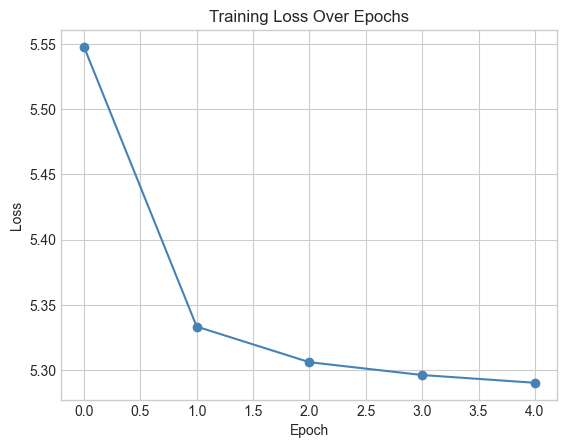

In [ ]:
fig, ax = plt.subplots()
ax.plot(loss_history, marker='o', color = "steelblue")
ax.set_title("Training Loss Over Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
plt.show()

Cross-entropy loss on the training set for the CBOW model. 

:::

It's often sufficient to train these models for only a few epochs in order to learn interesting embeddings. 

::: {#fig-trained-embeddings }

In [ ]:
visualize_embeddings(model, tokenizer, data)

2-dimensional visualization of the token embeddings after training. *Note*: This figure is interactive -- playing around is encouraged. Several clusters within the embedding space reflect words which rhyme or which have other similarities, such as "beetle,"  "bottle," and "battle" from *Fox in Socks*. 


:::

## Studying Embeddings

Recall that we can use the cosine similarity to study relationships between tokens. Let's compare cosine similarities between `Fox` (from *Fox in Socks*) and several other tokens: 

In [ ]:
base_token = "Fox"

comparison_tokens = [
    " socks",     # from Fox in Socks
    " box",       # from Fox in Socks
    " broom",     # from Fox in Socks
    " ham",       # from Green Eggs and Ham
    " Christmas", # from How the Grinch Stole Christmas
    " hat"        # from The Cat in the Hat
    ]

for token in comparison_tokens:
    idx = data.token_to_idx[tokenizer.encode(token)[0]]
    embedding = model.embeddings.weight[idx]
    print(f"Cosine similarity between '{base_token}' and '{token}': {cosine_similarity(model.embeddings.weight[data.token_to_idx[tokenizer.encode(base_token)[0]]], embedding):.4f}")

Cosine similarity between 'Fox' and ' socks': 0.9214
Cosine similarity between 'Fox' and ' box': 0.7902
Cosine similarity between 'Fox' and ' broom': 0.6654
Cosine similarity between 'Fox' and ' ham': 0.4122
Cosine similarity between 'Fox' and ' Christmas': -0.5328
Cosine similarity between 'Fox' and ' hat': -0.3071


We observe that the similarity between `Fox` and the tokens which appear in the same story (i.e. nearby) is larger that between `Fox` and common tokens from the other Dr. Seuss texts on which we trained. This grouping may be helpful in downstream learning tasks; for example, a model which aims to predict which Dr. Seuss book a given sentence came from could make use of the fact that ` socks` and ` box` are similarly predictive of *Fox in Socks*; this similarity could allow us to reduce the parameter count and guard against overfitting. 

## References

## References